# Data cleaning procedures

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('df.csv')
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 52 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Unnamed: 0                                  3654 non-null   int64         
 1   date                                        3654 non-null   datetime64[ns]
 2   open                                        3654 non-null   float64       
 3   high                                        3654 non-null   float64       
 4   low                                         3654 non-null   float64       
 5   close                                       3654 non-null   float64       
 6   volume                                      3654 non-null   float64       
 7   log_return                                  3654 non-null   float64       
 8   proxy_realised_variance                     3654 non-null   float64       
 9   proxy_re

In [3]:
cols_to_check = [
    "gold_close", "gold_vol",
    "silver_close", "silver_vol",
    "brent_close", "brent_vol",
    "dji_close", "dji_vol",
    "spx_close", "spx_vol",
    "rut_close", "rut_vol",
    "nasdaq_close", "nasdaq_vol",
    "usdcny_close", "usdeur_close",
    "vix_close"
]

(df[cols_to_check] == 0).sum()

gold_close        0
gold_vol         60
silver_close      0
silver_vol      225
brent_close       0
brent_vol        16
dji_close         0
dji_vol           0
spx_close         0
spx_vol           1
rut_close         0
rut_vol           3
nasdaq_close      0
nasdaq_vol        0
usdcny_close      0
usdeur_close      0
vix_close         0
dtype: int64

In [4]:
vol_cols = [
    "gold_vol",
    "silver_vol",
    "brent_vol",
    "spx_vol",
    "rut_vol"
]

# fill forward for exogoneous volume columns

for col in vol_cols:
    df.loc[df[col] == 0, col] = np.nan
df[vol_cols] = df[vol_cols].ffill()

(df[cols_to_check] == 0).sum()

gold_close      0
gold_vol        0
silver_close    0
silver_vol      0
brent_close     0
brent_vol       0
dji_close       0
dji_vol         0
spx_close       0
spx_vol         0
rut_close       0
rut_vol         0
nasdaq_close    0
nasdaq_vol      0
usdcny_close    0
usdeur_close    0
vix_close       0
dtype: int64

In [5]:
# drop irrelevant columns
cols_to_drop = ['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume',
                'proxy_realised_variance', 'proxy_realised_volatility', 
                'fng', 'value_classification', 'google_trend', 'gtrend_change',
                'RV_1', 'RV_7', 'RV_30', "blockchain_log_n_transactions","blockchain_log_transaction_fee_usd","blockchain_log_n_unique_addresses",
                "blockchain_log_transaction_volume+usd"]
df = df.drop(columns=cols_to_drop)

In [6]:
# check for na values
df.isna().sum()

df[df["blockchain_log_mempool_count"].isna()][["date"]]

# na values are in contiguous time block so safe to drop them 
df = df.dropna(subset=["blockchain_log_mempool_count"])

# check for na values again
df.isna().sum()

date                                            0
log_return                                      0
realized_variance                               0
realized_volatility                             0
fng_change                                    602
gtrend_pct_change                               0
gold_close                                      0
gold_vol                                        0
silver_close                                    0
silver_vol                                      0
brent_close                                     0
brent_vol                                       0
dji_close                                       0
dji_vol                                         0
spx_close                                       0
spx_vol                                         0
rut_close                                       0
rut_vol                                         0
nasdaq_close                                    0
nasdaq_vol                                      0


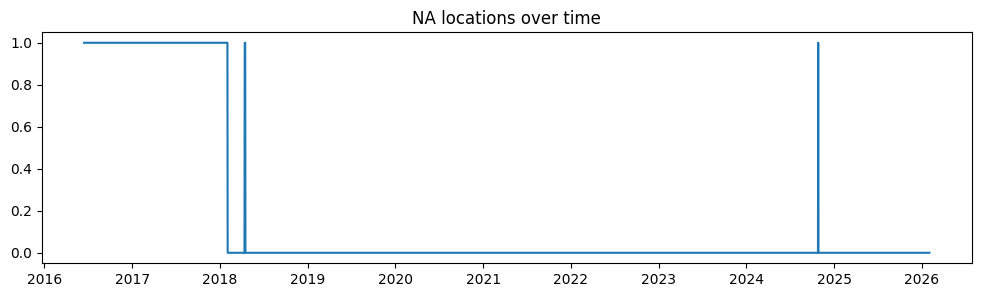

In [7]:
df[df["fng_change"].isna()][["date"]]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.plot(df["date"], df["fng_change"].isna())
plt.title("NA locations over time")
plt.show()

In [8]:
# remove fng column for now due to problematic na values
df = df.drop(columns=["fng_change"])



In [9]:
# convert raw levels to returns

price_cols = [
    "gold_close",
    "silver_close",
    "brent_close",
    "dji_close",
    "spx_close",
    "rut_close",
    "nasdaq_close",
    "usdcny_close",
    "usdeur_close"
]

vol_cols = [
    "gold_vol",
    "silver_vol",
    "brent_vol",
    "dji_vol",
    "spx_vol",
    "rut_vol",
    "nasdaq_vol",
    "vix_close"
]

meta_cols = [
    "hash-rate",
    "difficulty",
    "median-confirmation-time",
    "blockchain_log_mempool_count"
]

for col in price_cols:
    df[f"{col}_ret"] = np.log(df[col]).diff()

for col in vol_cols:
    df[f"{col}_chg"] = np.log(df[col]).diff()

for col in meta_cols:
    df[f"{col}_chg"] = np.log(df[col]).diff()

# drop original price and volume columns
df = df.drop(columns=price_cols + vol_cols + meta_cols)

# drop first row for which returns are na
df = df.dropna()

df = df.rename(columns=lambda x: x.replace("_vol_", "_volume_"))

df.head()

,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,brent_volume_chg,dji_volume_chg,spx_volume_chg,rut_volume_chg,nasdaq_volume_chg,vix_close_chg,hash-rate_chg,difficulty_chg,median-confirmation-time_chg,blockchain_log_mempool_count_chg
135,2016-06-15,0.019990,0.000528,0.022974,-0.138889,0.048912,0.154753,0.114522,-0.141196,8.976393,...,0.468585,0.004152,-0.058899,-0.058899,-0.063166,-0.017717,0.146603,0.0,0.089524,-0.003401
136,2016-06-16,0.096743,0.001641,0.040503,0.225806,0.032894,0.084044,0.034834,0.704898,9.729602,...,-0.224912,-0.023432,0.023300,0.023300,0.027134,-0.038982,-0.033006,0.0,-0.380307,-0.060516
137,2016-06-17,-0.022997,0.003730,0.061075,0.039474,-0.054144,-0.035212,-0.034919,-0.362618,9.547441,...,-0.184784,0.994922,0.311160,0.301013,0.353963,0.002063,0.000000,0.0,-0.037979,-0.003399
138,2016-06-18,0.008907,0.001710,0.041354,-0.177215,-0.075424,-0.124417,-0.069753,-0.418154,9.169094,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064958,0.0,-0.182322,-0.033404
139,2016-06-19,0.012790,0.000586,0.024214,-0.076923,-0.075072,-0.097766,-0.024354,-0.288327,8.602203,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.107246,0.0,-0.255933,-0.132230


In [10]:
df.info()
len(df)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3518 entries, 135 to 3652
Data columns (total 32 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        3518 non-null   datetime64[ns]
 1   log_return                                  3518 non-null   float64       
 2   realized_variance                           3518 non-null   float64       
 3   realized_volatility                         3518 non-null   float64       
 4   gtrend_pct_change                           3518 non-null   float64       
 5   blockchain_diff_log_n_transactions          3518 non-null   float64       
 6   blockchain_diff_log_transaction_fee_usd     3518 non-null   float64       
 7   blockchain_diff_log_n_unique_addresses      3518 non-null   float64       
 8   blockchain_diff_log_transaction_volume_usd  3518 non-null   float64       
 9   log_vo

3518

In [11]:
# export to csv
df.to_csv('df_clean.csv', index=False)